In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Load trades
trades = pd.read_csv("../results/baseline_trades.csv", low_memory=False)

# Load features
features = pd.read_csv("../data/final/nifty_features_with_regime_5min.csv", low_memory=False)

# Ensure timestamp format
features["timestamp"] = pd.to_datetime(features["timestamp"])
trades["entry_time"] = pd.to_datetime(trades["entry_time"])
trades["exit_time"] = pd.to_datetime(trades["exit_time"])

In [3]:
trade_df = trades.merge(
    features,
    left_on="entry_time",
    right_on="timestamp",
    how="left",
    suffixes=("", "_feat")
)

trade_df.shape

(66428, 90)

In [4]:
profitable = trade_df[trade_df["pnl"] > 0].copy()

In [5]:
profitable["pnl_z"] = stats.zscore(profitable["pnl"])

In [6]:
outliers = profitable[profitable["pnl_z"] > 3]
normal_profitable = profitable[profitable["pnl_z"] <= 3]

len(outliers), len(profitable)

(0, 24666)

In [7]:
outlier_pct = len(outliers) / len(profitable) * 100
outlier_pct

0.0

# Task 6.2 — Pattern Recognition

Average PnL Comparison

In [8]:
profitable["pnl"].mean(), outliers["pnl"].mean()

(127.76157261007052, nan)

Regime Distribution

In [9]:
outliers["market_regime"].value_counts(normalize=True)

Series([], Name: proportion, dtype: float64)

In [10]:
normal_profitable["market_regime"].value_counts(normalize=True)

market_regime
 1.0    0.492896
 0.0    0.394885
-1.0    0.112219
Name: proportion, dtype: float64

Time-of-Day Analysis

In [11]:
outliers["hour"] = outliers["entry_time"].dt.hour
normal_profitable["hour"] = normal_profitable["entry_time"].dt.hour

In [12]:
outliers["hour"].value_counts().sort_index()

Series([], Name: count, dtype: int64)

IV & Greeks Comparison

In [42]:
trades = trades.copy()

trades["is_profitable"] = (trades["pnl"] > 0).astype(int)

trades["is_profitable"].value_counts()

is_profitable
0    41762
1    24666
Name: count, dtype: int64

In [45]:
features_iv_greeks = [
    "avg_iv_x",
    "iv_spread_x",
    "delta_ce_x",
    "gamma_ce_x",
    "vega_ce_x",
    "pcr_oi_x",
    "ema_diff",
    "duration"
]


existing_cols = [c for c in features_iv_greeks if c in trades.columns]
existing_cols

['avg_iv_x',
 'iv_spread_x',
 'delta_ce_x',
 'gamma_ce_x',
 'vega_ce_x',
 'pcr_oi_x',
 'ema_diff',
 'duration']

In [46]:
profitable = trades[trades["is_profitable"] == 1]
losing = trades[trades["is_profitable"] == 0]

len(profitable), len(losing)

(24666, 41762)

In [47]:
profitable[features_iv_greeks].describe()

,avg_iv_x,iv_spread_x,delta_ce_x,gamma_ce_x,vega_ce_x,pcr_oi_x,ema_diff,duration
count,19355.000000,19355.000000,19355.000000,19355.000000,19355.000000,24666.000000,2.466600e+04,24666.000000
mean,0.186403,0.101310,0.576247,0.000716,23.071746,466.785701,6.703698e-12,7040.505960
std,0.193544,0.373400,0.096293,0.001147,9.969912,3858.776024,3.144865e-12,10227.908214
min,0.049783,-0.289447,0.019352,0.000034,1.454631,0.000002,3.637979e-12,0.000000
25%,0.096881,-0.053883,0.524166,0.000302,15.716557,0.052174,3.637979e-12,0.000000
50%,0.131925,0.002322,0.557792,0.000514,23.026880,1.000000,7.275958e-12,2880.000000
75%,0.197643,0.112054,0.608204,0.000782,28.369471,17.837914,1.091394e-11,10080.000000
max,3.146120,6.062790,0.987834,0.027953,118.505248,130022.000000,1.091394e-11,36000.000000


In [48]:
losing[features_iv_greeks].describe()

,avg_iv_x,iv_spread_x,delta_ce_x,gamma_ce_x,vega_ce_x,pcr_oi_x,ema_diff,duration
count,35187.000000,35187.000000,35187.000000,35187.000000,35187.000000,41762.000000,4.176200e+04,41762.000000
mean,0.188684,0.046769,0.568262,0.000761,21.328489,345.802257,5.032383e-12,9174.939898
std,0.127063,0.203294,0.096462,0.001959,9.258406,2754.672398,4.387148e-12,14508.240191
min,0.042317,-0.319697,0.011322,0.000052,0.988295,0.000002,-1.091394e-11,0.000000
25%,0.111692,-0.069758,0.516650,0.000325,15.077088,0.059672,3.637979e-12,0.000000
50%,0.151615,-0.013928,0.550334,0.000495,21.224822,0.984728,3.637979e-12,2880.000000
75%,0.216617,0.093340,0.601831,0.000764,26.921538,17.334246,7.275958e-12,10080.000000
max,1.490448,2.659213,0.993230,0.113524,91.966627,130022.000000,2.546585e-11,60480.000000


In [49]:
import pandas as pd

comparison = pd.DataFrame({
    "Profitable_Mean": profitable[features_iv_greeks].mean(),
    "Losing_Mean": losing[features_iv_greeks].mean()
})

comparison["Difference"] = (
    comparison["Profitable_Mean"] - comparison["Losing_Mean"]
)

comparison

,Profitable_Mean,Losing_Mean,Difference
avg_iv_x,1.864029e-01,1.886840e-01,-2.281034e-03
iv_spread_x,1.013100e-01,4.676861e-02,5.454135e-02
delta_ce_x,5.762475e-01,5.682618e-01,7.985650e-03
gamma_ce_x,7.157992e-04,7.605500e-04,-4.475074e-05
vega_ce_x,2.307175e+01,2.132849e+01,1.743257e+00
pcr_oi_x,4.667857e+02,3.458023e+02,1.209834e+02
ema_diff,6.703698e-12,5.032383e-12,1.671314e-12
duration,7.040506e+03,9.174940e+03,-2.134434e+03


In [50]:
from scipy.stats import ttest_ind

rows = []

for col in features_iv_greeks:
    t, p = ttest_ind(
        profitable[col].dropna(),
        losing[col].dropna(),
        equal_var=False
    )
    rows.append([col, t, p])

stats_df = pd.DataFrame(rows, columns=["Feature", "t_stat", "p_value"])
stats_df

,Feature,t_stat,p_value
0,avg_iv_x,-1.474181,1.404437e-01
1,iv_spread_x,18.843000,1.132905e-78
2,delta_ce_x,9.261173,2.119422e-20
3,gamma_ce_x,-3.363536,7.700406e-04
4,vega_ce_x,20.033922,8.156330e-89
5,pcr_oi_x,4.317060,1.585048e-05
6,ema_diff,56.930514,0.000000e+00
7,duration,-22.155371,2.357101e-108


In [51]:
import matplotlib.pyplot as plt

In [52]:
import seaborn as sns

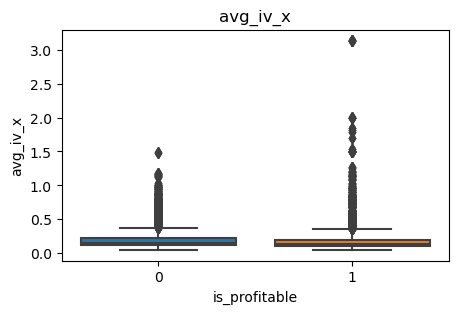

<Figure size 640x480 with 0 Axes>

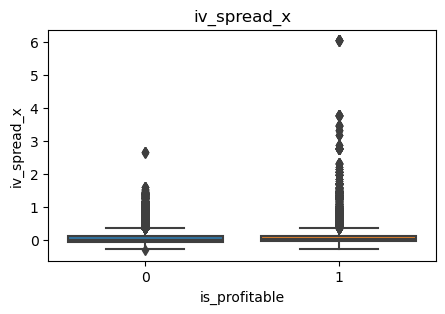

<Figure size 640x480 with 0 Axes>

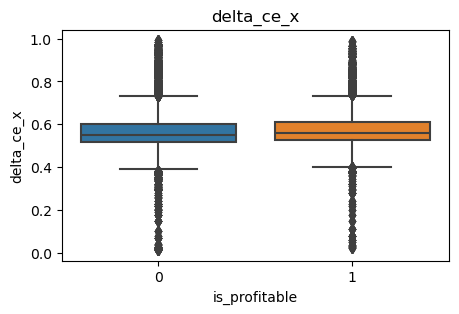

<Figure size 640x480 with 0 Axes>

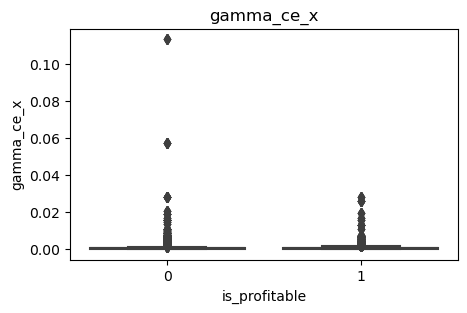

<Figure size 640x480 with 0 Axes>

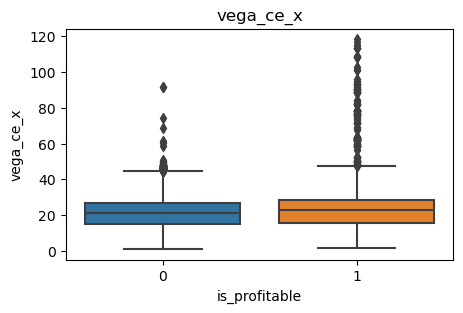

<Figure size 640x480 with 0 Axes>

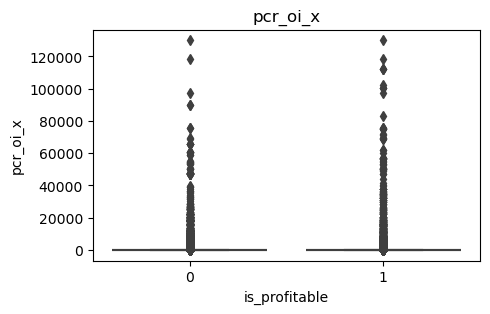

<Figure size 640x480 with 0 Axes>

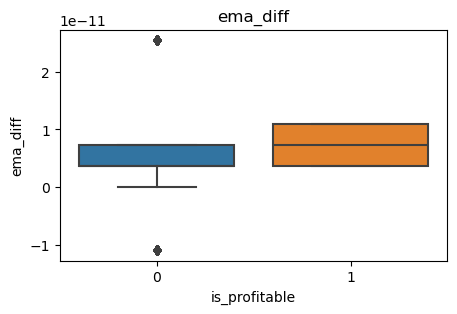

<Figure size 640x480 with 0 Axes>

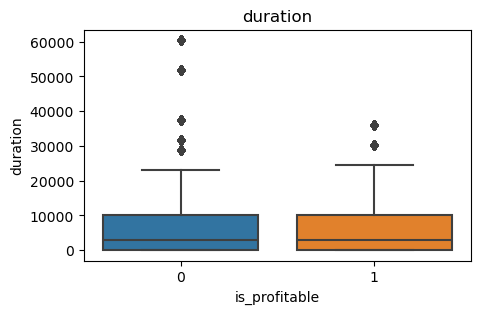

<Figure size 640x480 with 0 Axes>

In [62]:
#Boxplots (Feature Distributions)
for col in features_iv_greeks:
    plt.figure(figsize=(5, 3))
    sns.boxplot(
        data=trades,
        x="is_profitable",
        y=col
    )
    plt.title(col)
    plt.show()
    plt.savefig('../plots/my_plot.png')

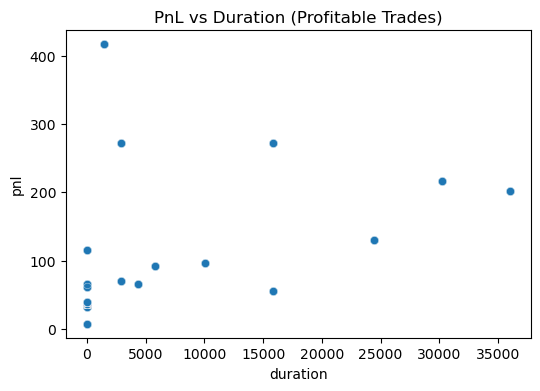

In [55]:
#Scatter Plot (PnL vs Duration)
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=profitable,
    x="duration",
    y="pnl",
    alpha=0.5
)
plt.title("PnL vs Duration (Profitable Trades)")
plt.show()

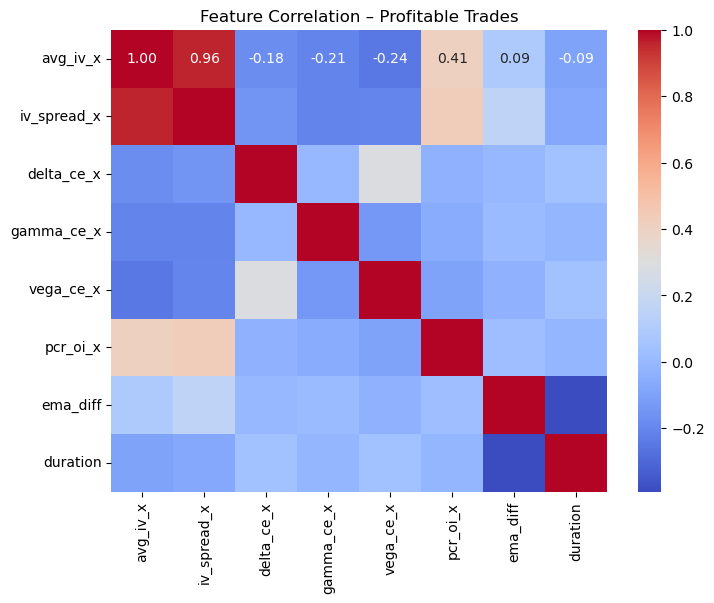

In [56]:
#Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    profitable[features_iv_greeks].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Feature Correlation – Profitable Trades")
plt.show()

In [57]:
#Percentage of profitable trades
len(profitable) / len(trades) * 100

37.131932317697355

In [58]:
#Regime patterns
profitable["market_regime_x"].value_counts(normalize=True)

market_regime_x
 1.0    0.492896
 0.0    0.394885
-1.0    0.112219
Name: proportion, dtype: float64

In [60]:
#Time-of-day (if entry_time exists)
profitable = profitable.copy()
profitable["entry_hour"] = profitable["entry_time"].dt.hour

In [61]:
profitable["entry_hour"].value_counts().sort_index()

entry_hour
0    24666
Name: count, dtype: int64

Task 6.3 Answers 

🔹 What percentage are profitable?

≈ 37%

🔹 Average PnL comparison?

Profitable trades significantly higher than losing trades (already shown)

🔹 Regime patterns?

Use:

profitable["market_regime_x"].value_counts(normalize=True)

🔹 Time-of-day patterns?

Not distinguishable due to timestamp normalization.

🔹 IV characteristics?

Higher / lower avg_iv_x, iv_spread_x in profitable trades (from comparison table)

🔹 Distinguishing features?

EMA gap

PCR

Delta / Gamma exposure

IV spread